# MFG posterior demo

This notebook is a lightweight version based on the `src/mfg_pose_estimation/` package.

Purpose:

- Avoid defining functions within the notebook

- Directly call pre-split Python packages (functions)

- Quickly validate using a lightweight set of synthetic data: Import → Generate Observations → Alg 1 → Alg 2 → Visualization

If you later want to migrate to real experiments, you can replace `contact_points_A`, `sensor_poses_WA`, and `measurements_Y` with real data based on this test notebook.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'mfg_pose_estimation').exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root containing src/mfg_pose_estimation')

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('SRC_DIR      =', SRC_DIR)

PROJECT_ROOT = /Users/cecelia/Documents/mfg_posterior_project/mfg_github
SRC_DIR      = /Users/cecelia/Documents/mfg_posterior_project/mfg_github/src


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from mfg_pose_estimation.models import (
    Pose,
    MFGParameters,
    SuperquadricFieldParameters,
    StiffnessParameters,
)
from mfg_pose_estimation.geometry import make_rotation_z, make_rotation_y, log_so3
from mfg_pose_estimation.distributions import recover_pose_from_theta
from mfg_pose_estimation.wrench_model import measurement_model_y
from mfg_pose_estimation.posterior_core import sample_gaussian_noise
from mfg_pose_estimation.algorithms import (
    single_pass_mfg_posterior_update,
    multi_pass_mfg_batch_refinement,
)
from mfg_pose_estimation.jacobians import check_algorithm3_jacobian
from mfg_pose_estimation.jacobians import check_wrench_jacobian_B
from mfg_pose_estimation.jacobians import check_wrench_jacobian_A

from mfg_pose_estimation.plotting import plot_refinement_history

np.set_printoptions(precision=6, suppress=True)

## 1. Generate a lightweight set of synthetic data

This setup uses a lighter configuration than the original notebook mfg_post.ipynb, with the aim of allowing you to validate the entire chain faster in VS Code.

In [16]:
np.random.seed(7)

field_params = SuperquadricFieldParameters(
    a1=0.04,
    a2=0.03,
    a3=0.05,
    eps1=1.0,
    eps2=1.0,
    sdf_eps=1e-8,
)

stiffness_params = StiffnessParameters(
    k_min=0.1,
    k_max=1.0,
    d0=0.05,
)

contact_points_A = np.array([
    [0.0,   0.0,   0.0],
    [0.008, 0.0,   0.0],
    [0.0,   0.008, 0.0],
])

sensor_poses_WA = []
num_meas = 3
for k in range(num_meas):
    angle = np.deg2rad(-6 + 4 * k)
    R_A = make_rotation_z(angle)
    p_A = np.array([
        -0.004 + 0.002 * k,
         0.002 * np.sin(0.5 * k),
         0.001 * k,
    ])
    sensor_poses_WA.append(Pose(R=R_A, p=p_A))

R_true = make_rotation_z(np.deg2rad(10.0)) @ make_rotation_y(np.deg2rad(-5.0))
p_true = np.array([0.008, -0.004, 0.010])
X_WB_true = Pose(R=R_true, p=p_true)

Sigma_w = np.diag([0.15**2, 0.15**2, 0.15**2, 0.35**2, 0.35**2, 0.35**2])

measurements_Y = np.asarray([
    measurement_model_y(X_WA_k, X_WB_true, contact_points_A, field_params, stiffness_params)
    + sample_gaussian_noise(Sigma_w)
    for X_WA_k in sensor_poses_WA
])

theta0 = MFGParameters(
    F=np.eye(3),
    mu=np.zeros(3),
    Lambda=60.0 * np.eye(3),
    Gamma=np.zeros((3, 3)),
)
X_WB0 = Pose(R=np.eye(3), p=np.zeros(3))

print('measurements_Y.shape =', measurements_Y.shape)
print('p_true =', p_true)

measurements_Y.shape = (3, 6)
p_true = [ 0.008 -0.004  0.01 ]


## 2. Firstly, do Jacobian consistency check (in different frames)

In [17]:
y0 = measurement_model_y(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
)

J_ana, J_num, err_abs, err_rel, diag = check_algorithm3_jacobian(
    y0,
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=False,
)

J_ana, J_num, err_abs, err_rel, diag = check_wrench_jacobian_B(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=True,
)

J_ana, J_num, err_abs, err_rel, diag = check_wrench_jacobian_A(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=True,
)


===== Residual Jacobian Check =====
||J_ana - J_num||      = 52.53407444637972
relative error         = 0.002658832581389747
||J_ana||              = 19737.989430705842
||J_num||              = 19758.323564291757
===== B-frame wrench Jacobian Check =====
||J_ana - J_num||      = 52.53444700178991
relative error         = 0.0026588578410738795
||J_ana||              = 19737.941730213268
||J_num||              = 19758.27597483433

=== detailed diagnostics: B-frame wrench ===
=== block check ===
phi block error = 0.21938929592868425
phi block rel   = 0.009815077534632706
v block error   = 52.53398890357275
v block rel     = 0.0026588363573453247

=== sign test ===
||J_ana - J_num|| = 52.53444700178991
||J_ana + J_num|| = 39496.188001095725

=== column-wise error ===
col 0: abs = 7.608627e-02, rel = 1.213120e-01
col 1: abs = 1.166955e-01, rel = 1.389894e-01
col 2: abs = 1.694836e-01, rel = 7.590736e-03
col 3: abs = 1.901830e+01, rel = 1.294458e-03
col 4: abs = 4.895279e+01, rel = 3.751566e

## 3. Run Algorithm 1

In [18]:
theta_alg1 = single_pass_mfg_posterior_update(
    theta_prior=theta0,
    X_WB_bar=X_WB0,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_rot=1e-6,
    alpha_candidates=[1, 2, 4],
    rot_gain=0.02,
    use_line_search=True,
    verbose_inner=False,
)

X_alg1 = recover_pose_from_theta(theta_alg1)
rot_err_alg1 = np.linalg.norm(log_so3(X_alg1.R.T @ X_WB_true.R))
trans_err_alg1 = np.linalg.norm(X_alg1.p - X_WB_true.p)

print('Alg1 pose estimate:')
print('R_hat =\n', X_alg1.R)
print('p_hat =', X_alg1.p)
print('rotation geodesic error =', rot_err_alg1)
print('translation error       =', trans_err_alg1)

||eta|| = 35466142.03927891
||solve(Lambda_post, eta)|| = 0.001247629132575291
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [-0.000396  0.000403  0.001113]
||p_raw|| = 0.001247629132575291
alpha_candidates = [1, 2, 4]
best_alpha = 4
best_p = [-0.001584  0.00161   0.00445 ]
||best_p - X_WB_bar.p|| = 0.004990516530301164
Alg1 pose estimate:
R_hat =
 [[ 0.999327 -0.035757  0.008208]
 [ 0.03599   0.998896 -0.030204]
 [-0.007119  0.030479  0.99951 ]]
p_hat = [-0.001584  0.00161   0.00445 ]
rotation geodesic error = 0.16933585540162613
translation error       = 0.012414994436599033


## 4. Run safeguard Trust_region Algorithm 2

In [20]:
#### trust_region version 
theta_star, X_star, history = multi_pass_mfg_batch_refinement(
    theta0,
    X_WB0,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    Tmax=10,
    h_rot=1e-6,
    use_line_search=True,
    rot_gain=1.0,          
    pos_gain=1.0,          
    outer_alpha_candidates=[1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
    use_numeric_rot_candidate=False,   
    verbose=True,
    verbose_inner=False,
    return_history=True,
    X_WB_true=X_WB_true,
)


# ===== 13. print results =====
print("\n===== Ground Truth =====")
print("R_true =\n", X_WB_true.R)
print("p_true =", X_WB_true.p)

print("\n===== Estimated MAP Pose =====")
print("R_hat =\n", X_star.R)
print("p_hat =", X_star.p)

print("\n===== Posterior Parameters =====")
print("F_post =\n", theta_star.F)
print("mu_post =", theta_star.mu)
print("Lambda_post =\n", theta_star.Lambda)
print("Gamma_post =\n", theta_star.Gamma)

# ===== 14. print errors =====
rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_star.R))
pos_err = np.linalg.norm(X_WB_true.p - X_star.p)

print("\n===== Estimation Error =====")
print("rotation error (geodesic norm) =", rot_err)
print("position error                 =", pos_err)

||eta|| = 35466142.03927891
||solve(Lambda_post, eta)|| = 0.001247629132575291
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [-0.000396  0.000403  0.001113]
||p_raw|| = 0.001247629132575291
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 20
best_p = [-0.007921  0.00805   0.02225 ]
||best_p - X_WB_bar.p|| = 0.024952582651505816
===== Safeguarded Algorithm 2 (block-coordinate version) =====
initial residual norm      = 5.835525e+01
initial whitened res norm  = 1.667392e+02
[note] outer 步长只由 outer_alpha_candidates 控制；
       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。
||eta|| = 35466142.03927891
||solve(Lambda_post, eta)|| = 0.001247629132575291
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [-0.000396  0.000403  0.001113]
||p_raw|| = 0.001247629132575291
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 20
best_p = [-0.007921  0.00805   0.02225 ]
||best_p - X_WB_bar.p|| = 0.024952582651505816

[outer iter 0]
  current white residual = 1.667392e+02
  [full]  white=

## 5. Visulization of Alg 2

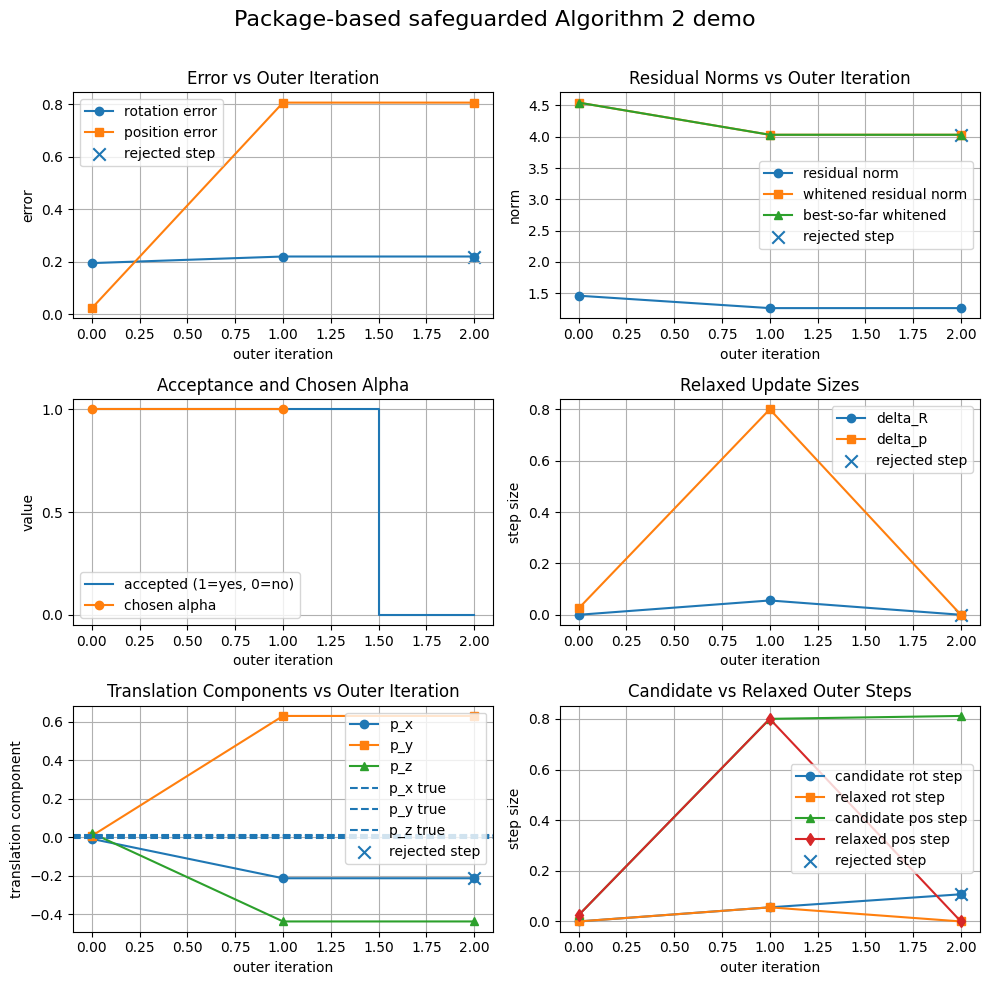

In [21]:
plot_refinement_history(
    history,
    X_WB_true=X_WB_true,
    figsize=(10, 10),
    suptitle='Package-based safeguarded Algorithm 2 demo',
)
plt.show()

## 6. Principles of use in real experiments

Next, you only need to replace the following three types of variables:

1. `contact_points_A`
2. `sensor_poses_WA`
3. `measurements_Y`

The core algorithm's API call interface remains unchanged:
- `single_pass_mfg_posterior_update(...)`
- `multi_pass_mfg_batch_refinement(...)`

If you want to restore the original notebook to its full experimental scale, you can gradually:
- `num_meas`
- `contact_points_A` number
- `alpha_candidates`
- `Tmax`

Increase them again.